# 02 - Exploratory Data Analysis & Visualization

**Objective:** Explore the cleaned basketball dataset through statistical summaries and visualizations to uncover patterns, correlations, and insights that will guide our modeling decisions.

**Sections:**
1. Data overview & descriptive stats
2. Distribution analysis
3. Skewness analysis
4. Correlation analysis
5. Scatter plots - key relationships
6. Offense vs Defense quadrant analysis
7. Top vs Bottom teams comparison
8. Home vs Away performance
9. Correlation heatmap

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

## 1. Load Data & Descriptive Statistics

In [2]:
# load cleaned data
df = pd.read_csv("../data/processed/cleaned_basketball_data.csv")
print(f"Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Dataset: 10,000 rows × 37 columns


,id,year,rank,school,games,wins,losses,win_percentage,conference_wins,conference_losses,...,offensive_rebounds,total_rebounds,assists,steals,blocks,turnovers,personal_fouls,points,opponent_points,simple_rating
0,1,2021,1,Villanova,38,30,8,0.789,16,4,...,10.3,34.8,11.9,6.0,2.2,9.9,14.9,71.7,62.7,19.31
1,2,2021,2,Providence,33,27,6,0.818,14,3,...,10.5,37.6,13.2,5.0,3.7,11.4,16.0,71.5,66.2,13.08
2,3,2021,3,UConn,33,23,10,0.697,13,6,...,13.8,40.4,14.0,5.9,6.4,11.8,16.8,74.8,65.3,16.40
3,4,2021,4,Creighton,35,23,12,0.657,12,7,...,9.6,38.1,13.3,5.5,4.3,14.1,13.6,69.2,66.4,11.34
4,5,2021,5,Marquette,32,19,13,0.594,11,8,...,7.8,34.8,16.0,7.8,5.2,12.4,17.4,74.0,71.6,11.36


In [3]:
# Compute derived metrics inline for exploratory analysis
# These will be formally created in notebook 04 (Feature Engineering)

df["assist_turnover_ratio"] = np.where(df["turnovers"] == 0, 0, df["assists"] / df["turnovers"])
df["home_win_pct"] = np.where((df["home_wins"] + df["home_losses"]) == 0, 0.5, df["home_wins"] / (df["home_wins"] + df["home_losses"]))
df["away_win_pct"] = np.where((df["away_wins"] + df["away_losses"]) == 0, 0.5, df["away_wins"] / (df["away_wins"] + df["away_losses"]))
df["home_advantage"] = df["home_win_pct"] - df["away_win_pct"]
df["scoring_efficiency"] = np.where(df["field_goal_attempts"] == 0, 0, df["points"] / df["field_goal_attempts"])
df["defensive_pressure"] = df["steals"] + df["blocks"]
df["point_diff"] = df["points"] - df["opponent_points"]
df["conf_win_pct"] = np.where((df["conference_wins"] + df["conference_losses"]) == 0, 0.5, df["conference_wins"] / (df["conference_wins"] + df["conference_losses"]))

print(f"Computed 8 exploratory features inline for EDA")

Computed 8 exploratory features inline for EDA


In [4]:
# basic stats
print(df.describe().round(2))
print("\nData types:")
print(df.dtypes)

             id      year      rank     games      wins   losses  \
count  10000.00  10000.00  10000.00  10000.00  10000.00  10000.0   
mean     248.41   2000.02      8.37     31.37     20.43     13.6   
std      144.14     12.40      4.64      6.11      9.06      6.8   
min        1.00   1979.00      1.00     19.00      5.00      2.0   
25%      123.00   1989.00      4.00     27.00     13.00      8.0   
50%      248.00   2000.00      8.00     32.00     20.00     14.0   
75%      374.00   2011.00     12.00     36.00     28.00     19.0   
max      496.00   2021.00     16.00     41.00     36.00     25.0   

       win_percentage  conference_wins  conference_losses  home_wins  ...  \
count        10000.00         10000.00           10000.00   10000.00  ...   
mean             0.60             8.55               9.94      11.06  ...   
std              0.19             5.14               5.39       4.90  ...   
min              0.19             0.00               1.00       2.00  ...   
25

## 2. Distribution of Key Metrics

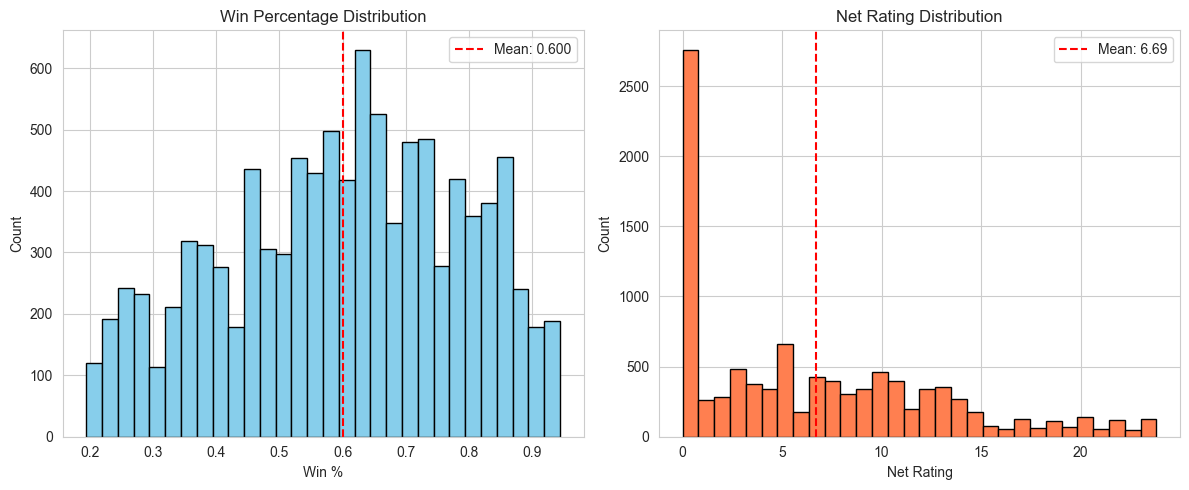

In [5]:
# distribution of win percentage and net rating
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df['win_percentage'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Win %')
axes[0].set_ylabel('Count')
axes[0].set_title('Win Percentage Distribution')
axes[0].axvline(df['win_percentage'].mean(), color='red', linestyle='--', label=f"Mean: {df['win_percentage'].mean():.3f}")
axes[0].legend()

axes[1].hist(df['net_rating'], bins=30, color='coral', edgecolor='black')
axes[1].set_xlabel('Net Rating')
axes[1].set_ylabel('Count')
axes[1].set_title('Net Rating Distribution')
axes[1].axvline(df['net_rating'].mean(), color='red', linestyle='--', label=f"Mean: {df['net_rating'].mean():.2f}")
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Skewness Analysis

In [6]:
# skewness analysis
from scipy.stats import skew

# calculate skewness for all numeric columns
skewness = df.select_dtypes(include=[np.number]).skew().sort_values(ascending=False)

print("Interpretation Guide:")
print("  |skew| < 0.5  : Fairly symmetric")
print("  0.5-1.0       : Moderately skewed")
print("  |skew| > 1.0  : Highly skewed\n")

# sort by absolute skewness
skewness_abs = skewness.abs().sort_values(ascending=False)
for col in skewness_abs.index:
    skew_val = skewness[col]
    abs_skew = abs(skew_val)
    
    if abs_skew < 0.5:
        level = "Fairly symmetric"
    elif abs_skew < 1.0:
        level = "Moderately skewed"
    else:
        level = "HIGHLY SKEWED"
    
    print(f"{col:30s}: {skew_val:7.3f}  [{level}]")

# identify highly skewed features
highly_skewed = skewness_abs[skewness_abs > 1.0]
print(f"\n{len(highly_skewed)} features are highly skewed (|skew| > 1.0)")
if len(highly_skewed) > 0:
    print("\nHighly skewed features:")
    for col in highly_skewed.index:
        print(f"  - {col}: {skewness[col]:.3f}")

Interpretation Guide:
  |skew| < 0.5  : Fairly symmetric
  0.5-1.0       : Moderately skewed
  |skew| > 1.0  : Highly skewed

net_rating                    :   0.757  [Moderately skewed]
assist_turnover_ratio         :   0.658  [Moderately skewed]
field_goals                   :   0.310  [Fairly symmetric]
blocks                        :   0.296  [Fairly symmetric]
3_pointer_attempts            :  -0.273  [Fairly symmetric]
games                         :  -0.268  [Fairly symmetric]
free_throws                   :   0.260  [Fairly symmetric]
personal_fouls                :   0.257  [Fairly symmetric]
home_win_pct                  :  -0.257  [Fairly symmetric]
scoring_efficiency            :   0.247  [Fairly symmetric]
win_percentage                :  -0.242  [Fairly symmetric]
offensive_rebounds            :   0.224  [Fairly symmetric]
effective_field_goal_percentage:   0.210  [Fairly symmetric]
free_throw_attempts           :   0.185  [Fairly symmetric]
field_goal_percentage         :

## 4. Correlation with Win Percentage

Top correlations with win percentage:
win_percentage      1.000000
away_win_pct        0.027926
simple_rating       0.026083
conf_win_pct        0.025030
net_rating          0.024690
wins                0.023463
points              0.022886
offensive_rating    0.022460
free_throws         0.021016
point_diff          0.020901
Name: win_percentage, dtype: float64


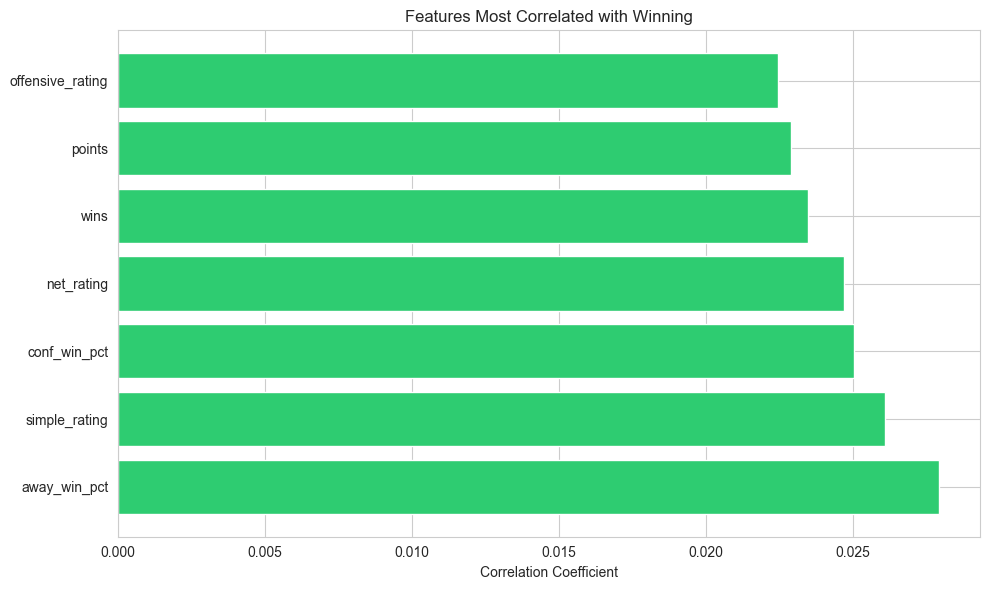

In [7]:
# correlation with win percentage
corr_with_win = df.corr(numeric_only=True)['win_percentage'].sort_values(ascending=False)
print("Top correlations with win percentage:")
print(corr_with_win.head(10))

# plot top correlations
top_features = corr_with_win.head(8).index[1:]  # exclude win_percentage itself
plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr_with_win[top_features]]
plt.barh(top_features, corr_with_win[top_features], color=colors)
plt.xlabel('Correlation Coefficient')
plt.title('Features Most Correlated with Winning')
plt.tight_layout()
plt.show()

## 5. Scatter Plots - Win % vs Key Metrics

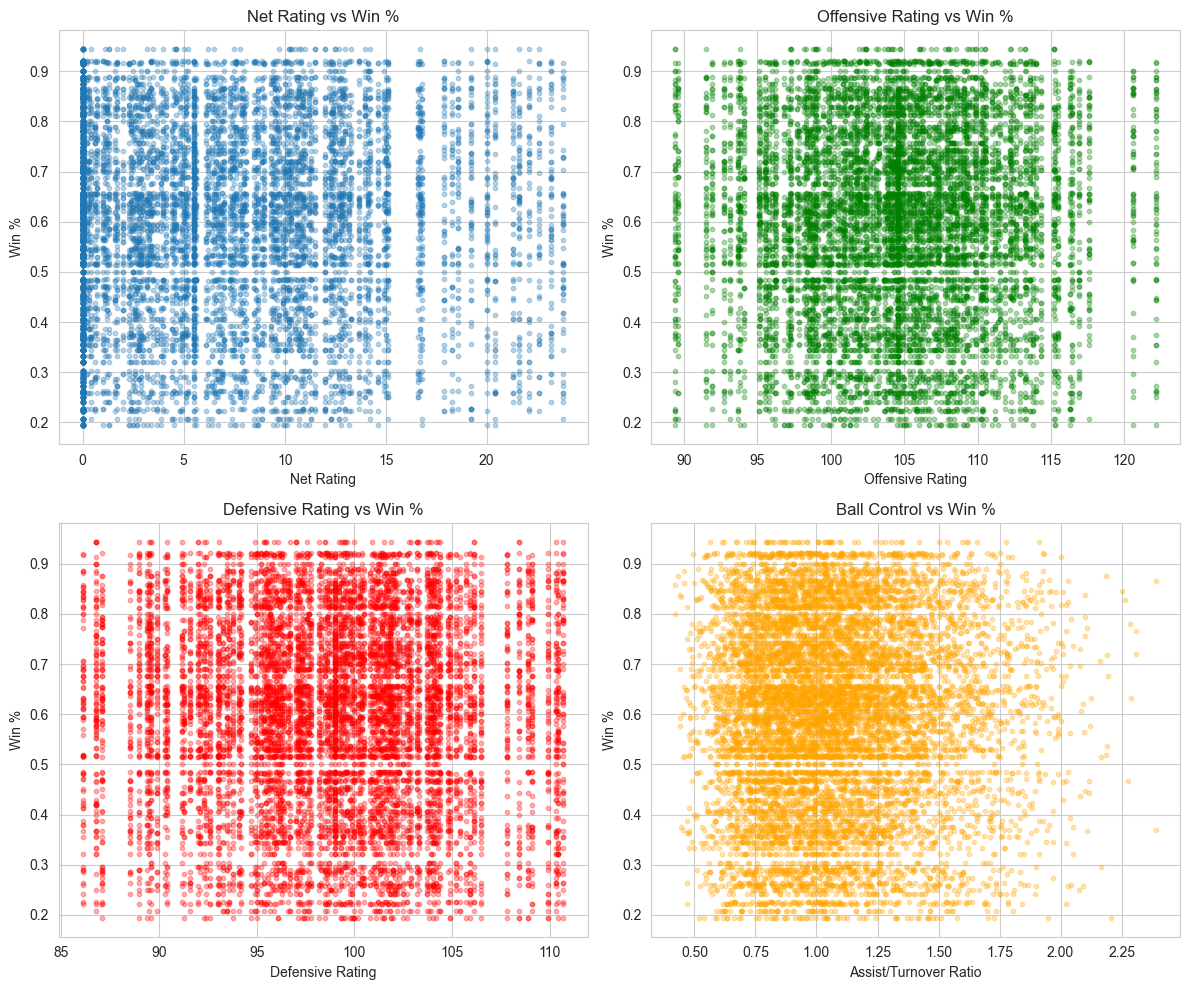

In [8]:
# scatter plots - win% vs key metrics
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].scatter(df['net_rating'], df['win_percentage'], alpha=0.3, s=10)
axes[0, 0].set_xlabel('Net Rating')
axes[0, 0].set_ylabel('Win %')
axes[0, 0].set_title('Net Rating vs Win %')

axes[0, 1].scatter(df['offensive_rating'], df['win_percentage'], alpha=0.3, s=10, color='green')
axes[0, 1].set_xlabel('Offensive Rating')
axes[0, 1].set_ylabel('Win %')
axes[0, 1].set_title('Offensive Rating vs Win %')

axes[1, 0].scatter(df['defensive_rating'], df['win_percentage'], alpha=0.3, s=10, color='red')
axes[1, 0].set_xlabel('Defensive Rating')
axes[1, 0].set_ylabel('Win %')
axes[1, 0].set_title('Defensive Rating vs Win %')

axes[1, 1].scatter(df['assist_turnover_ratio'], df['win_percentage'], alpha=0.3, s=10, color='orange')
axes[1, 1].set_xlabel('Assist/Turnover Ratio')
axes[1, 1].set_ylabel('Win %')
axes[1, 1].set_title('Ball Control vs Win %')

plt.tight_layout()
plt.show()

## 6. Offense vs Defense Quadrant Analysis

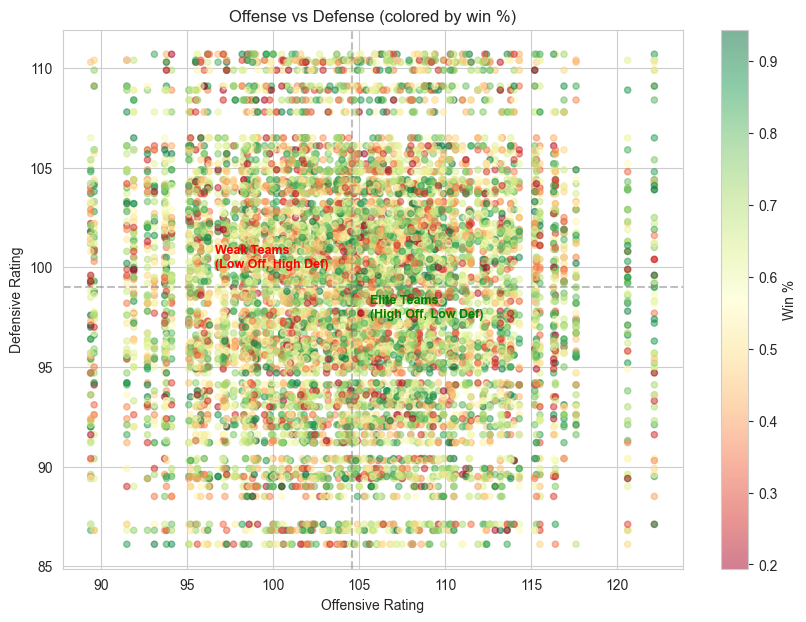

In [9]:
# offensive vs defensive rating colored by win %
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df['offensive_rating'], df['defensive_rating'], 
            c=df['win_percentage'], cmap='RdYlGn', alpha=0.5, s=20)
plt.colorbar(scatter, label='Win %')
plt.xlabel('Offensive Rating')
plt.ylabel('Defensive Rating')
plt.title('Offense vs Defense (colored by win %)')
plt.axhline(df['defensive_rating'].median(), color='gray', linestyle='--', alpha=0.5)
plt.axvline(df['offensive_rating'].median(), color='gray', linestyle='--', alpha=0.5)

# annotate quadrants
off_med = df['offensive_rating'].median()
def_med = df['defensive_rating'].median()
plt.text(off_med + 1, def_med - 1.5, 'Elite Teams\n(High Off, Low Def)', fontsize=9, color='green', fontweight='bold')
plt.text(off_med - 8, def_med + 1, 'Weak Teams\n(Low Off, High Def)', fontsize=9, color='red', fontweight='bold')

plt.show()

## 7. Top 10 vs Bottom 10 Teams

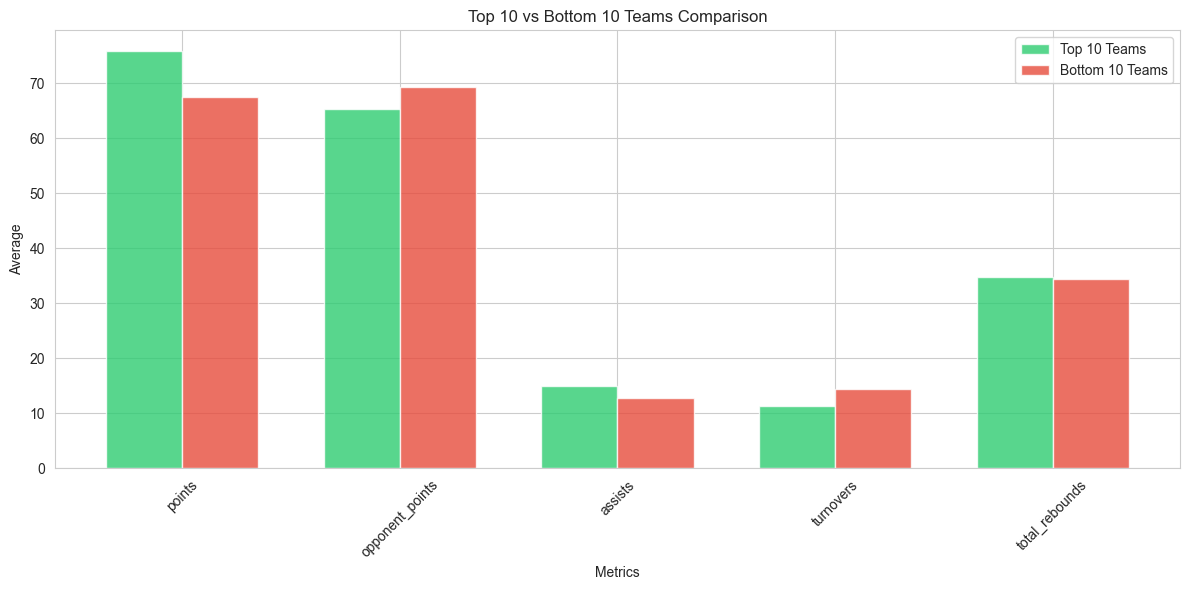

In [10]:
# compare top and bottom teams
top_teams = df.nsmallest(10, 'rank')
bottom_teams = df.nlargest(10, 'rank')

metrics = ['points', 'opponent_points', 'assists', 'turnovers', 'total_rebounds']
avg_top = top_teams[metrics].mean()
avg_bottom = bottom_teams[metrics].mean()

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, avg_top, width, label='Top 10 Teams', color='#2ecc71', alpha=0.8)
ax.bar(x + width/2, avg_bottom, width, label='Bottom 10 Teams', color='#e74c3c', alpha=0.8)

ax.set_xlabel('Metrics')
ax.set_ylabel('Average')
ax.set_title('Top 10 vs Bottom 10 Teams Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

## 8. Home vs Away Performance

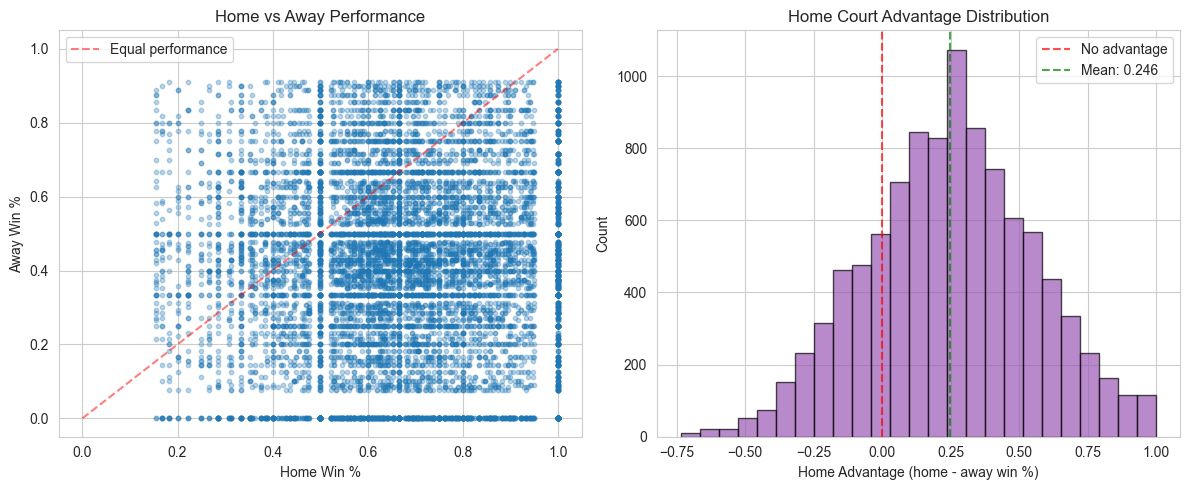

In [11]:
# home vs away performance
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df['home_win_pct'], df['away_win_pct'], alpha=0.3, s=10)
axes[0].plot([0, 1], [0, 1], 'r--', alpha=0.5, label='Equal performance')
axes[0].set_xlabel('Home Win %')
axes[0].set_ylabel('Away Win %')
axes[0].set_title('Home vs Away Performance')
axes[0].legend()

axes[1].hist(df['home_advantage'], bins=25, color='#9b59b6', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Home Advantage (home - away win %)')
axes[1].set_ylabel('Count')
axes[1].set_title('Home Court Advantage Distribution')
axes[1].axvline(0, color='red', linestyle='--', alpha=0.7, label='No advantage')
axes[1].axvline(df['home_advantage'].mean(), color='green', linestyle='--', alpha=0.7, label=f"Mean: {df['home_advantage'].mean():.3f}")
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Correlation Heatmap

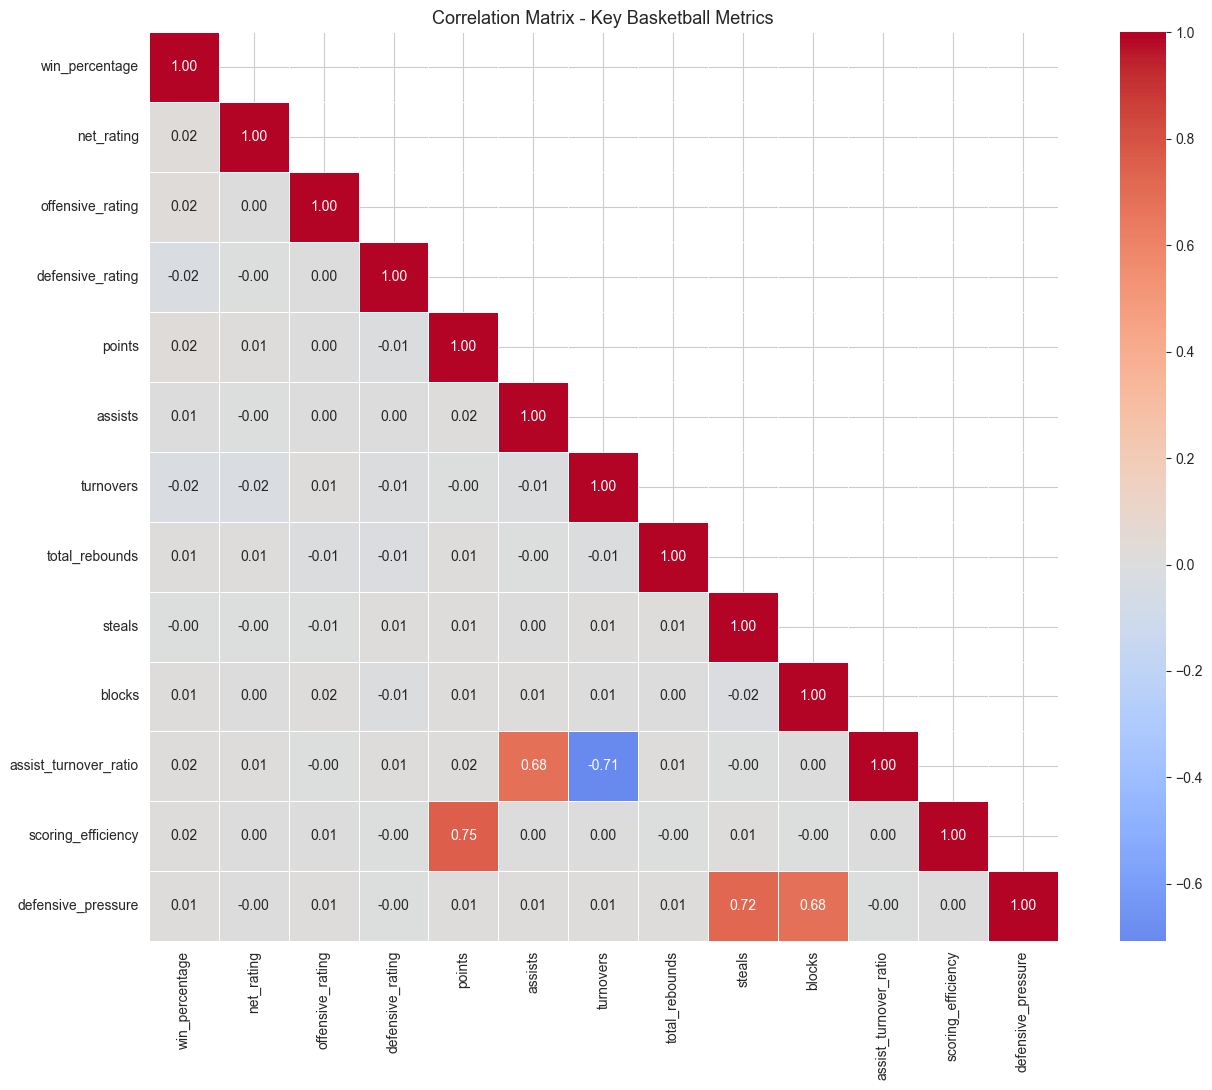

In [12]:
# correlation heatmap of key columns
plt.figure(figsize=(14, 11))
key_cols = ['win_percentage', 'net_rating', 'offensive_rating', 'defensive_rating',
            'points', 'assists', 'turnovers', 'total_rebounds', 'steals', 'blocks',
            'assist_turnover_ratio', 'scoring_efficiency', 'defensive_pressure']

corr = df[key_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, mask=mask)
plt.title('Correlation Matrix - Key Basketball Metrics', fontsize=13)
plt.tight_layout()
plt.show()